<a href="https://colab.research.google.com/github/sandip-1996/PRML_exercise_code_example/blob/main/beta_prior_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

total sucess: 54
total failure: 46
likelihood mean of mu: 0.54
prior mean of mu: 0.5
Posterior mean of mu: 0.5384615384615384
Predictive P(x=1 | D): 0.5384615384615384
Predictive P(x=0 | D): 0.46153846153846156


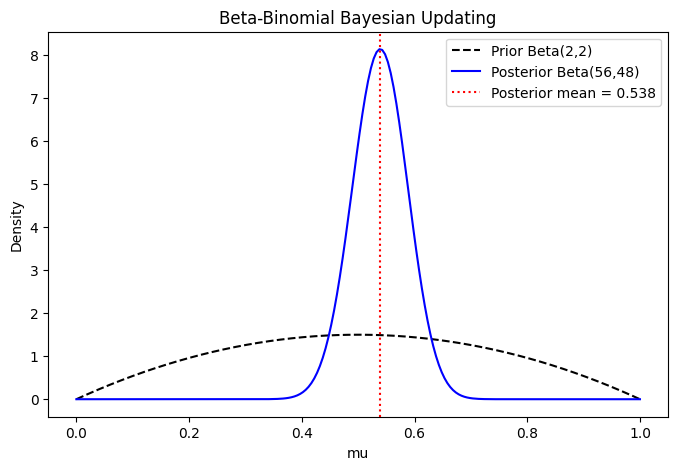

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import beta, binom

a, b = 2, 2   # prior ~ Beta(2,2) : symmetric around 0.5

# random dataset after n flips
data_array = np.random.randint(0,2,size = 100)
data_list = data_array.tolist()
m = data_list.count(1) # success
l = data_list.count(0) # failure
n = l + m

# -----------------------------
# Posterior distribution parameters
# -----------------------------
a_post = a + m
b_post = b + l

# Posterior mean (our "best prediction" of mu)
mu_MLE = m/n
mu_prior = a/(a+b)
mu_pred = a_post / (a_post + b_post)
print("total sucess:", m)
print("total failure:", l)
print("likelihood mean of mu:", mu_MLE)
print("prior mean of mu:", mu_prior)
print("Posterior mean of mu:", mu_pred)

# Posterior distribution for mu
x = np.linspace(0, 1, 200)
prior_pdf = beta.pdf(x, a, b)
posterior_pdf = beta.pdf(x, a_post, b_post)

# -----------------------------
# Predictive distribution for next observation x_next
# -----------------------------
# P(x_next=1 | D) = posterior mean of mu
p_next_1 = mu_pred
p_next_0 = 1 - mu_pred
print("Predictive P(x=1 | D):", p_next_1)
print("Predictive P(x=0 | D):", p_next_0)
# -----------------------------
# Plot prior vs posterior
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(x, prior_pdf, 'k--', label=f'Prior Beta({a},{b})')
plt.plot(x, posterior_pdf, 'b-', label=f'Posterior Beta({a_post},{b_post})')
plt.axvline(mu_pred, color='red', linestyle=':', label=f'Posterior mean = {mu_pred:.3f}')
plt.title("Beta-Binomial Bayesian Updating")
plt.xlabel("mu")
plt.ylabel("Density")
plt.legend()
plt.show()

